# Preparación para Modelado — Siniestros Fatales ONSV 2021–2025
**Curso:** Agentes Inteligentes | **Grupo 5**

Este notebook toma el dataset enriquecido (`siniestros_enriquecido.csv`) producido en el notebook 02
y lo prepara para el modelado supervisado. Los problemas de calidad del dato se resolvieron en el
notebook 01. El enriquecimiento externo se realizó en el notebook 02. Este notebook se ocupa
exclusivamente de decisiones de modelado (Géron, 2022).

1. Carga y verificación del dataset enriquecido
2. Imputación de nulos introducidos por el enriquecimiento externo
3. Selección de features con justificación por columna
4. Encoding de variables categóricas
5. Verificación del desbalance de clases
6. Split train/test
7. Aplicación de SMOTE (solo sobre train)
8. Exportación del dataset listo para modelado

## 0. Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent
DIR_FIGURAS = BASE_DIR / 'outputs' / 'figures'
DIR_PROCESADA = BASE_DIR / 'data' / 'procesada'
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
DIR_PROCESADA.mkdir(parents=True, exist_ok=True)

## 1. Carga y verificación del dataset enriquecido

In [9]:
df = pd.read_csv(DIR_PROCESADA / 'siniestros_enriquecido.csv', encoding='utf-8')

print(f'Dimensiones cargadas: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nNulos por columna (solo las que tienen nulos):')
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
for col, n in nulos.items():
    print(f'  {col}: {n:,} ({n/len(df)*100:.1f}%)')
print(f'\nVariable objetivo — distribución:')
print(df['CATEGORIA_SEVERIDAD'].value_counts())

Dimensiones cargadas: 9,106 filas × 56 columnas

Nulos por columna (solo las que tienen nulos):
  MTC_RVN_LONGITUD_KM: 4,094 (45.0%)
  MTC_RVN_N_CARRILES_MEDIANA: 4,094 (45.0%)
  MTC_RVN_SUPERFICIE_DOMINANTE: 4,094 (45.0%)
  MTC_RVN_ESTADO_DOMINANTE: 4,094 (45.0%)
  MTC_RVN_ES_CONCESIONADA: 4,094 (45.0%)
  MTC_RVN_CONCESION_PRINCIPAL: 4,094 (45.0%)
  MTC_RVN_CORREDOR_LOGISTICO: 4,094 (45.0%)
  MTC_RVN_N_TRAMOS: 4,094 (45.0%)
  IDH_UBIGEO: 281 (3.1%)
  IDH_2019: 281 (3.1%)
  IDH_ESP_VIDA_2019: 281 (3.1%)
  IDH_EDUC_SECUND_PCT_2019: 281 (3.1%)
  IDH_ANIOS_EDUC_2019: 281 (3.1%)
  IDH_INGRESO_PERCAP_2019: 281 (3.1%)
  IDH_POBLACION_2019: 281 (3.1%)

Variable objetivo — distribución:
CATEGORIA_SEVERIDAD
LEVE                7652
GRAVE_MORTALIDAD     929
GRAVE_LESIONADOS     525
Name: count, dtype: int64


## 2. Imputación de nulos del enriquecimiento externo

El enriquecimiento con la Red Vial Nacional del MTC tiene una cobertura del 55%,
lo que genera nulos en 8 columnas `MTC_RVN_*` para el 45% de los registros.
Estos corresponden principalmente a vías urbanas, rutas sin clasificar o registros
sin código de carretera válido.

El enriquecimiento con IDH tiene cobertura del 97%, dejando 3.1% de nulos en las
columnas `IDH_*`.

Las columnas `MTC_DEP_*` tienen cobertura del 100% y no requieren imputación.

**Estrategia:** imputar nulos numéricos con la mediana de su columna e imputar
nulos categóricos con la categoría `'SIN_DATO'`. La mediana es robusta a valores
extremos y no distorsiona la distribución (Han et al., 2012).

In [10]:
df_imp = df.copy()

# Columnas MTC_RVN con 45% de nulos
cols_mtc_rvn_num = [
    'MTC_RVN_LONGITUD_KM', 'MTC_RVN_N_CARRILES_MEDIANA',
    'MTC_RVN_ES_CONCESIONADA', 'MTC_RVN_N_TRAMOS'
]
cols_mtc_rvn_cat = [
    'MTC_RVN_SUPERFICIE_DOMINANTE', 'MTC_RVN_ESTADO_DOMINANTE',
    'MTC_RVN_CONCESION_PRINCIPAL', 'MTC_RVN_CORREDOR_LOGISTICO'
]

# Columnas IDH con 3.1% de nulos
cols_idh_num = [
    'IDH_UBIGEO', 'IDH_2019', 'IDH_ESP_VIDA_2019',
    'IDH_EDUC_SECUND_PCT_2019', 'IDH_ANIOS_EDUC_2019',
    'IDH_INGRESO_PERCAP_2019', 'IDH_POBLACION_2019'
]

# Imputar numéricos con mediana
for col in cols_mtc_rvn_num + cols_idh_num:
    if col in df_imp.columns and df_imp[col].isnull().sum() > 0:
        mediana = df_imp[col].median()
        df_imp[col] = df_imp[col].fillna(mediana)
        print(f'  {col}: imputado con mediana={mediana:.4f}')

# Imputar categóricos con SIN_DATO
for col in cols_mtc_rvn_cat:
    if col in df_imp.columns and df_imp[col].isnull().sum() > 0:
        df_imp[col] = df_imp[col].fillna('SIN_DATO')
        print(f'  {col}: imputado con SIN_DATO')

print(f'\nNulos restantes después de imputación: {df_imp.isnull().sum().sum()}')

  MTC_RVN_LONGITUD_KM: imputado con mediana=6543.5550
  MTC_RVN_N_CARRILES_MEDIANA: imputado con mediana=2.0000
  MTC_RVN_ES_CONCESIONADA: imputado con mediana=1.0000
  MTC_RVN_N_TRAMOS: imputado con mediana=1198.0000
  IDH_UBIGEO: imputado con mediana=130901.0000
  IDH_2019: imputado con mediana=0.5564
  IDH_ESP_VIDA_2019: imputado con mediana=77.0094
  IDH_EDUC_SECUND_PCT_2019: imputado con mediana=69.1025
  IDH_ANIOS_EDUC_2019: imputado con mediana=8.4770
  IDH_INGRESO_PERCAP_2019: imputado con mediana=914.8836
  IDH_POBLACION_2019: imputado con mediana=27932.1970
  MTC_RVN_SUPERFICIE_DOMINANTE: imputado con SIN_DATO
  MTC_RVN_ESTADO_DOMINANTE: imputado con SIN_DATO
  MTC_RVN_CONCESION_PRINCIPAL: imputado con SIN_DATO
  MTC_RVN_CORREDOR_LOGISTICO: imputado con SIN_DATO

Nulos restantes después de imputación: 0


## 3. Selección de features

**Criterio general (Provost & Fawcett, 2013):** se excluyen variables con
redundancia semántica, cardinalidad excesiva sin poder predictivo diferencial,
o que son derivaciones directas de la variable objetivo.

| Columna | Decisión | Razón |
|---|---|---|
| `CANTIDAD DE FALLECIDOS` | **Excluir** | Construye directamente la variable objetivo |
| `CANTIDAD DE LESIONADOS` | **Excluir** | Ídem |
| `MORTALIDAD_MULTIPLE` | **Excluir** | Componente directo de `CATEGORIA_SEVERIDAD` |
| `LESION_MULTIPLE` | **Excluir** | Ídem |
| `COD CARRETERA` | **Excluir** | 1,046 valores únicos; ya se usó como llave de cruce en nb02; redundante con `RED VIAL` |
| `PROVINCIA` | **Excluir** | 182 únicos; capturada por `DEPARTAMENTO` + `REGION_NATURAL` |
| `DISTRITO` | **Excluir** | 1,086 únicos; representado por coordenadas lat/lon |
| `CLASIFICACIÓN SEÑAL Nº 1` | **Excluir** | 85-94% SIN_DATO; capturada por `¿EXISTE SEÑAL VERTICAL?` |
| `CLASIFICACIÓN SEÑAL Nº 2` | **Excluir** | Ídem |
| `CAUSA ESPECÍFICA` | **Excluir** | 38 categorías altamente correladas con `CAUSA FACTOR PRINCIPAL` (7 categorías) |
| `IDH_UBIGEO` | **Excluir** | Código identificador, no variable predictora |
| `CATEGORIA_SEVERIDAD` | **Target (y)** | Variable objetivo del modelo |
| Resto | **Incluir** | Variables predictoras con cardinalidad manejable |

In [11]:
EXCLUIR = [
    'CANTIDAD DE FALLECIDOS', 'CANTIDAD DE LESIONADOS',
    'MORTALIDAD_MULTIPLE', 'LESION_MULTIPLE',
    'COD CARRETERA', 'PROVINCIA', 'DISTRITO',
    'CAUSA ESPECÍFICA',
    'IDH_UBIGEO',
]

# Excluir columnas de clasificación de señal (85-94% SIN_DATO)
excluir_señal = [c for c in df_imp.columns if 'CLASIFICACIÓN' in c.upper()]
EXCLUIR += excluir_señal

TARGET = 'CATEGORIA_SEVERIDAD'

excluir_real = [c for c in EXCLUIR if c in df_imp.columns]
no_encontradas = [c for c in EXCLUIR if c not in df_imp.columns]
if no_encontradas:
    print(f'⚠ No encontradas: {no_encontradas}')

X = df_imp.drop(columns=excluir_real + [TARGET], errors='ignore')
y = df_imp[TARGET]

print(f'Features seleccionadas ({X.shape[1]}):')
for col in X.columns:
    print(f'  {col} — {X[col].dtype} — {X[col].nunique()} únicos')

Features seleccionadas (44):
  CLASE SINIESTRO — str — 11 únicos
  CANTIDAD DE VEHICULOS DAÑADOS — int64 — 9 únicos
  DEPARTAMENTO — str — 25 únicos
  ZONA — str — 3 únicos
  TIPO DE VÍA — str — 13 únicos
  RED VIAL — str — 5 únicos
  COORDENADAS LATITUD — float64 — 9101 únicos
  COORDENADAS  LONGITUD — float64 — 9094 únicos
  CONDICIÓN CLIMÁTICA — str — 9 únicos
  ZONIFICACIÓN — str — 6 únicos
  CARACTERÍSTICAS DE VÍA — str — 10 únicos
  PERFIL LONGITUDINAL VÍA — str — 3 únicos
  SUPERFICIE DE CALZADA — str — 8 únicos
  ¿EXISTE SEÑAL VERTICAL? — str — 3 únicos
  ¿EXISTE SEÑAL HORIZONTAL? — str — 3 únicos
  CAUSA FACTOR PRINCIPAL — str — 7 únicos
  AÑO — int64 — 5 únicos
  MES — int64 — 12 únicos
  DIA_SEMANA — int64 — 7 únicos
  ES_FIN_SEMANA — int64 — 2 únicos
  HORA_NUM — int64 — 24 únicos
  FRANJA_HORARIA — str — 4 únicos
  REGION_NATURAL — str — 3 únicos
  MTC_RVN_LONGITUD_KM — float64 — 129 únicos
  MTC_RVN_N_CARRILES_MEDIANA — float64 — 5 únicos
  MTC_RVN_SUPERFICIE_DOMINANTE — 

## 4. Encoding de variables categóricas

Random Forest y XGBoost no aceptan strings directamente. Se aplica **Label Encoding**
para todas las columnas categóricas, guardando cada encoder en un diccionario para
permitir la inversión si se necesita interpretar resultados con SHAP.

Breiman (2001) señala que Random Forest maneja bien Label Encoding porque los splits
en cada nodo operan por umbral numérico, no por proximidad ordinal.

In [12]:
from sklearn.preprocessing import LabelEncoder

cols_cat = X.select_dtypes(include='object').columns.tolist()
cols_num = X.select_dtypes(include=np.number).columns.tolist()

print(f'Columnas categóricas a encodear ({len(cols_cat)}):')
for c in cols_cat:
    print(f'  {c} — {X[c].nunique()} categorías')
print(f'\nColumnas numéricas sin cambio ({len(cols_num)}): {cols_num}')

Columnas categóricas a encodear (19):
  CLASE SINIESTRO — 11 categorías
  DEPARTAMENTO — 25 categorías
  ZONA — 3 categorías
  TIPO DE VÍA — 13 categorías
  RED VIAL — 5 categorías
  CONDICIÓN CLIMÁTICA — 9 categorías
  ZONIFICACIÓN — 6 categorías
  CARACTERÍSTICAS DE VÍA — 10 categorías
  PERFIL LONGITUDINAL VÍA — 3 categorías
  SUPERFICIE DE CALZADA — 8 categorías
  ¿EXISTE SEÑAL VERTICAL? — 3 categorías
  ¿EXISTE SEÑAL HORIZONTAL? — 3 categorías
  CAUSA FACTOR PRINCIPAL — 7 categorías
  FRANJA_HORARIA — 4 categorías
  REGION_NATURAL — 3 categorías
  MTC_RVN_SUPERFICIE_DOMINANTE — 7 categorías
  MTC_RVN_ESTADO_DOMINANTE — 5 categorías
  MTC_RVN_CONCESION_PRINCIPAL — 15 categorías
  MTC_RVN_CORREDOR_LOGISTICO — 34 categorías

Columnas numéricas sin cambio (25): ['CANTIDAD DE VEHICULOS DAÑADOS', 'COORDENADAS LATITUD', 'COORDENADAS  LONGITUD', 'AÑO', 'MES', 'DIA_SEMANA', 'ES_FIN_SEMANA', 'HORA_NUM', 'MTC_RVN_LONGITUD_KM', 'MTC_RVN_N_CARRILES_MEDIANA', 'MTC_RVN_ES_CONCESIONADA', 'MTC_RVN

/tmp/ipykernel_24817/2476434620.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = X.select_dtypes(include='object').columns.tolist()


In [13]:
X_enc = X.copy()
encoders = {}

for col in cols_cat:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    encoders[col] = le

# Encodear variable objetivo
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

print(f'Clases en variable objetivo: {list(le_target.classes_)}')
print(f'Encodeo: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')
print(f'\nX_enc shape: {X_enc.shape}')
print(f'Nulos en X_enc: {X_enc.isnull().sum().sum()}')

Clases en variable objetivo: ['GRAVE_LESIONADOS', 'GRAVE_MORTALIDAD', 'LEVE']
Encodeo: {'GRAVE_LESIONADOS': np.int64(0), 'GRAVE_MORTALIDAD': np.int64(1), 'LEVE': np.int64(2)}

X_enc shape: (9106, 44)
Nulos en X_enc: 0


## 5. Verificación del desbalance de clases

In [14]:
conteo = Counter(y_enc)
print('Distribución de clases (antes de SMOTE):')
for clase, n in sorted(conteo.items()):
    nombre = le_target.classes_[clase]
    print(f'  {clase} ({nombre}): {n:,} ({n/len(y_enc)*100:.1f}%)')

Distribución de clases (antes de SMOTE):
  0 (GRAVE_LESIONADOS): 525 (5.8%)
  1 (GRAVE_MORTALIDAD): 929 (10.2%)
  2 (LEVE): 7,652 (84.0%)


## 6. Split train/test

El split debe ocurrir **antes** de SMOTE. Aplicar SMOTE sobre el dataset completo
y luego dividir introduce data leakage sintético: muestras generadas a partir de
registros de test podrían terminar en train, lo que inflaría artificialmente las
métricas del modelo (Géron, 2022).

Se usa `stratify=y_enc` para mantener la proporción de clases en ambos conjuntos.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

print(f'Train: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X_enc)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X_enc)*100:.0f}%)')
print(f'\nDistribución en train:')
for clase, n in sorted(Counter(y_train).items()):
    print(f'  {le_target.classes_[clase]}: {n:,} ({n/len(y_train)*100:.1f}%)')
print(f'\nDistribución en test:')
for clase, n in sorted(Counter(y_test).items()):
    print(f'  {le_target.classes_[clase]}: {n:,} ({n/len(y_test)*100:.1f}%)')

Train: 7,284 registros (80%)
Test:  1,822 registros (20%)

Distribución en train:
  GRAVE_LESIONADOS: 420 (5.8%)
  GRAVE_MORTALIDAD: 743 (10.2%)
  LEVE: 6,121 (84.0%)

Distribución en test:
  GRAVE_LESIONADOS: 105 (5.8%)
  GRAVE_MORTALIDAD: 186 (10.2%)
  LEVE: 1,531 (84.0%)


## 7. Aplicación de SMOTE (solo sobre train)

**Justificación (Bazarnovi & Mohammadian, 2024):** el desbalance extremo de clases
(~84% LEVE vs ~10% y ~6% para las clases graves) sesga el modelo hacia predecir
siempre la clase mayoritaria, obteniendo ~84% de accuracy sin aprender nada útil
sobre los casos graves.

SMOTE genera muestras sintéticas de las clases minoritarias interpolando entre
vecinos reales en el espacio de features, sin duplicar registros existentes.

**SMOTE se aplica exclusivamente sobre el conjunto de entrenamiento.** El conjunto
de test se mantiene sin modificar para evaluar el modelo sobre distribución real.

In [16]:
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_DISPONIBLE = True
except ImportError:
    print('⚠ imbalanced-learn no instalado. Ejecutar: pip install imbalanced-learn')
    SMOTE_DISPONIBLE = False

In [17]:
if SMOTE_DISPONIBLE:
    smote = SMOTE(sampling_strategy='not majority', random_state=42, k_neighbors=5)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    print('Distribución después de SMOTE (solo train):')
    conteo_bal = Counter(y_train_bal)
    for clase, n in sorted(conteo_bal.items()):
        nombre = le_target.classes_[clase]
        n_orig = Counter(y_train)[clase]
        print(f'  {clase} ({nombre}): {n:,} ({n/len(y_train_bal)*100:.1f}%) — antes: {n_orig:,}')

    print(f'\nTotal train después de SMOTE: {len(X_train_bal):,}')
    print(f'Muestras sintéticas añadidas: {len(X_train_bal) - len(X_train):,}')
    print(f'Test sin modificar: {len(X_test):,} registros')
else:
    X_train_bal, y_train_bal = X_train.values, y_train
    print('Continuando sin SMOTE.')

Distribución después de SMOTE (solo train):
  0 (GRAVE_LESIONADOS): 6,121 (33.3%) — antes: 420
  1 (GRAVE_MORTALIDAD): 6,121 (33.3%) — antes: 743
  2 (LEVE): 6,121 (33.3%) — antes: 6,121

Total train después de SMOTE: 18,363
Muestras sintéticas añadidas: 11,079
Test sin modificar: 1,822 registros


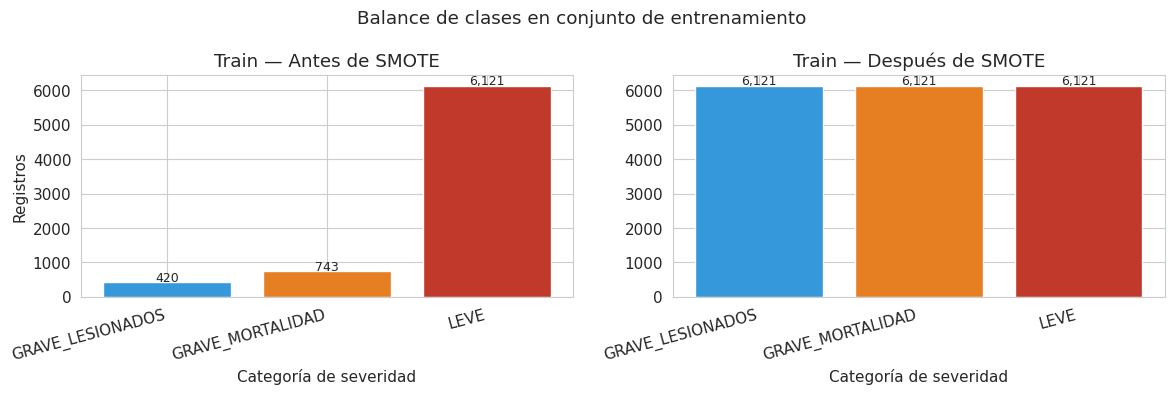

In [18]:
# Visualización: balance antes y después en train
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nombres_clases = le_target.classes_
colores = ['#3498db', '#e67e22', '#c0392b']

vals_antes = [Counter(y_train)[i] for i in range(len(nombres_clases))]
axes[0].bar(nombres_clases, vals_antes, color=colores)
axes[0].set_title('Train — Antes de SMOTE')
axes[0].set_ylabel('Registros')
for i, v in enumerate(vals_antes):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

if SMOTE_DISPONIBLE:
    vals_despues = [Counter(y_train_bal)[i] for i in range(len(nombres_clases))]
    axes[1].bar(nombres_clases, vals_despues, color=colores)
    axes[1].set_title('Train — Después de SMOTE')
    for i, v in enumerate(vals_despues):
        axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
else:
    axes[1].set_title('SMOTE no disponible')

for ax in axes:
    ax.set_xlabel('Categoría de severidad')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.suptitle('Balance de clases en conjunto de entrenamiento')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / 'balance_smote.png', dpi=150)
plt.show()

## 8. Exportación del dataset listo para modelado

In [19]:
import os
os.makedirs('data/procesada', exist_ok=True)

# Train balanceado (para entrenar el modelo)
X_train_bal_df = pd.DataFrame(X_train_bal, columns=X_enc.columns)
y_train_bal_df = pd.Series(
    le_target.inverse_transform(y_train_bal), name='CATEGORIA_SEVERIDAD'
)
y_train_bal_enc_df = pd.Series(y_train_bal, name='CATEGORIA_SEVERIDAD_ENC')
df_train = pd.concat([X_train_bal_df, y_train_bal_df, y_train_bal_enc_df], axis=1)
df_train.to_csv('data/procesada/siniestros_train.csv', index=False, encoding='utf-8')

# Test sin modificar (para evaluar el modelo)
X_test_df = pd.DataFrame(X_test, columns=X_enc.columns).reset_index(drop=True)
y_test_df = pd.Series(
    le_target.inverse_transform(y_test), name='CATEGORIA_SEVERIDAD'
)
y_test_enc_df = pd.Series(y_test, name='CATEGORIA_SEVERIDAD_ENC')
df_test = pd.concat([X_test_df, y_test_df, y_test_enc_df], axis=1)
df_test.to_csv('data/procesada/siniestros_test.csv', index=False, encoding='utf-8')

# Dataset completo procesado (sin SMOTE, para DBSCAN y análisis exploratorio)
df_completo = pd.concat([
    X_enc,
    pd.Series(le_target.inverse_transform(y_enc), name='CATEGORIA_SEVERIDAD'),
    pd.Series(y_enc, name='CATEGORIA_SEVERIDAD_ENC')
], axis=1)
df_completo.to_csv('data/procesada/siniestros_modelado.csv', index=False, encoding='utf-8')

print('✓ Archivos exportados:')
print(f'  siniestros_train.csv   — {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas (train + SMOTE)')
print(f'  siniestros_test.csv    — {df_test.shape[0]:,} filas × {df_test.shape[1]} columnas (test original)')
print(f'  siniestros_modelado.csv — {df_completo.shape[0]:,} filas × {df_completo.shape[1]} columnas (completo sin SMOTE)')

print(f'\nResumen metodológico:')
print(f'  Dataset entrada:        9,106 filas × 58 columnas (enriquecido)')
print(f'  Features seleccionadas: {X_enc.shape[1]}')
print(f'  Features excluidas:     {len(excluir_real)}')
print(f'  Train original:         {len(X_train):,} registros')
print(f'  Train tras SMOTE:       {len(X_train_bal):,} registros')
print(f'  Test (sin modificar):   {len(X_test):,} registros')

✓ Archivos exportados:
  siniestros_train.csv   — 18,363 filas × 46 columnas (train + SMOTE)
  siniestros_test.csv    — 1,822 filas × 46 columnas (test original)
  siniestros_modelado.csv — 9,106 filas × 46 columnas (completo sin SMOTE)

Resumen metodológico:
  Dataset entrada:        9,106 filas × 58 columnas (enriquecido)
  Features seleccionadas: 44
  Features excluidas:     11
  Train original:         7,284 registros
  Train tras SMOTE:       18,363 registros
  Test (sin modificar):   1,822 registros


## Referencias metodológicas

- **Bazarnovi & Mohammadian (2024)** — justificación de SMOTE para desbalance en datasets de accidentes de tránsito
- **Breiman (2001)** — Random Forest y compatibilidad con Label Encoding por splits numéricos
- **Géron (2022)** — pipeline general de ML y split train/test previo a SMOTE
- **Han, Kamber & Pei (2012)** — imputación con mediana para variables numéricas
- **Provost & Fawcett (2013)** — criterios de selección de features por redundancia semántica y cardinalidad